In [1]:
import matplotlib.pyplot as plt
from scipy import stats
import bisect
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [2]:
def calc_mu_sigma(k, e, vs):
    mu = (k-vs)*e + vs*(1-e)
    sigma = k*e*(1-e)
    return mu, sigma

class ResponseSimulator:

    def __init__(self, n: int, esp: float):
        self.esp = esp
        self.n = n

    def calc_best_query_num(self):
        INF = 10**9

        best_cost = INF
        best_q = 1
        for q in range(1, 15):
            cost = self.inference_score(q)
            if cost < best_cost:
                best_q = q
                best_cost = cost
        return best_q, best_cost
            
    def inference_correct_prob(self, query_num):

        mus = []
        for vs in range(201):
            mu, sigma = calc_mu_sigma(query_num, self.esp, vs)
            mus.append(mu)

        mu_mids = []
        for i in range(len(mus)-1):
            mu_mids.append((mus[i] + mus[i+1]) / 2)

        SAMPLE_N = 10 ** 5
        model_vs = query_num # 代表正解値。なんでもよいはず。

        mu, sigma = calc_mu_sigma(query_num, self.esp, model_vs)
        rng = np.random.default_rng()
        samples = rng.normal(mu, sigma, SAMPLE_N)

        correct_cnt = 0
        for sample in samples:
            if model_vs == bisect.bisect_left(mu_mids, max(0, round(sample))):
                correct_cnt += 1
        prob = correct_cnt / SAMPLE_N
        return prob

    def inference_score(self, query_num:int):
        if query_num == 1:
            return self.n**2
        grid_size = self.n**2
        prob = self.inference_correct_prob(query_num) ** grid_size
        # print(prob, self.esp, query_num)
        expected_cost = (grid_size / np.sqrt(query_num)) + grid_size * (1-prob)
        return expected_cost
    
    def env_setting(self, query_num: int):
        mus = []
        for vs in range(201):
            mu, sigma = calc_mu_sigma(query_num, self.esp, vs)
            mus.append(mu)

        mu_mids = []
        for i in range(len(mus)-1):
            mu_mids.append((mus[i] + mus[i+1]) / 2)

        self.query_num = query_num
        self.mu_mids = mu_mids

    def calc_true_val_from_response(self, resp_val):
        return bisect.bisect_left(self.mu_mids, resp_val)

In [3]:
N = 20
ESP = 0.01
response_simulator = ResponseSimulator(n=N, esp=ESP)
best_query_num, _ = response_simulator.calc_best_query_num()

print(best_query_num)
response_simulator.env_setting(best_query_num)
response_simulator.mu_mids

10


[0.5900000000000001,
 1.57,
 2.55,
 3.5299999999999994,
 4.51,
 5.49,
 6.47,
 7.449999999999999,
 8.43,
 9.41,
 10.39,
 11.370000000000001,
 12.35,
 13.33,
 14.309999999999999,
 15.29,
 16.27,
 17.25,
 18.23,
 19.21,
 20.189999999999998,
 21.17,
 22.15,
 23.13,
 24.11,
 25.09,
 26.07,
 27.049999999999997,
 28.03,
 29.009999999999998,
 29.990000000000002,
 30.97,
 31.950000000000003,
 32.93,
 33.91,
 34.89,
 35.870000000000005,
 36.849999999999994,
 37.83,
 38.81,
 39.79,
 40.769999999999996,
 41.75,
 42.730000000000004,
 43.709999999999994,
 44.69,
 45.67,
 46.65,
 47.629999999999995,
 48.61,
 49.59,
 50.57,
 51.55,
 52.53,
 53.510000000000005,
 54.489999999999995,
 55.47,
 56.45,
 57.43,
 58.41,
 59.39,
 60.370000000000005,
 61.349999999999994,
 62.33,
 63.31,
 64.28999999999999,
 65.27000000000001,
 66.25,
 67.22999999999999,
 68.21000000000001,
 69.19,
 70.17,
 71.15,
 72.13,
 73.11,
 74.09,
 75.07,
 76.05,
 77.03,
 78.00999999999999,
 78.99000000000001,
 79.97,
 80.94999999999999,


In [4]:
# N = 10

# for esp in np.arange(0.01, 0.1, 0.01):
#     response_simulator = ResponseSimulator(N, esp)
#     best_q, best_cost = response_simulator.calc_best_query_num()
#     print(esp, best_q, best_cost)

In [5]:
# class ResponseSimulator:

#     def __init__(self, query_num: int, esp: float):
#         mus = []
#         for vs in range(201):
#             mu, sigma = calc_mu_sigma(query_num, esp, vs)
#             mus.append(mu)

#         mu_mids = []
#         for i in range(len(mus)-1):
#             mu_mids.append((mus[i] + mus[i+1]) / 2)

#         self.mus = mus
#         self.mu_mids = mu_mids
#         self.query_num = query_num
#         self.esp = esp
    
#     def inference_correct_prob(self):
#         SAMPLE_N = 10000
#         model_vs = self.query_num # 代表正解値。なんでもよいはず。

#         mu, sigma = calc_mu_sigma(self.query_num, self.esp, model_vs)
#         rng = np.random.default_rng()
#         samples = rng.normal(mu, sigma, SAMPLE_N)

#         correct_cnt = 0
#         for sample in samples:
#             if model_vs == bisect.bisect_left(self.mu_mids, sample):
#                 correct_cnt += 1
#         prob = correct_cnt / SAMPLE_N
#         return prob

#     def inference_score(self, N:int):
#         if self.query_num == 1:
#             return N**2, 0
#         grid_size = N**2
#         prob = self.inference_correct_prob() ** (N**2)
#         expected_cost = (grid_size / np.sqrt(self.query_num)) + grid_size * (1-prob)
#         return expected_cost, prob

#     def calc_best_

In [6]:
# N = 20
# plt.figure(figsize=(10, 5))

# for esp in np.arange(0.01, 0.07, 0.01):
#     scores = {}
#     probs = {}
#     for q in range(1, 50):
#         response_simulator = ResponseSimulator(query_num=q, esp=esp)
#         score, prob = response_simulator.inference_score(N)
#         scores[q] = score
#         probs[q] = prob
#     plt.plot(scores.keys(), scores.values(), marker="o", label = f"esp = {esp:.2f}")
#     # plt.plot(probs.keys(), probs.values(), marker="o", label = f"esp = {esp:.2f}")
#     plt.legend()
# plt.show()

In [7]:
# def simulate(N: int ,esp: float, query_num: int):
#     # マップの大きさN
#     # 誤差 esp
#     # クエリする個数 query_num

#     # 1応答正解率 one_correct_prob
#     # マップ完答率 map_correct_prob
#     # 完答時期待得点 evaluate_score
    
#     mus = []
#     for vs in range(k+3):
#         mu, sigma = calc_mu_sigma(k, e, vs)
#         mus.append(mu)

#     mu_mids = []
#     for i in range(len(mus)-1):
#         mu_mids.append((mus[i] + mus[i+1]) / 2)



In [8]:
INF = 10**9
SAMPLE_N = 10000

def simulate(k, e, N=1000):

    mus = []
    for vs in range(k+3):
        mu, sigma = calc_mu_sigma(k, e, vs)
        mus.append(mu)

    mu_mids = []
    for i in range(len(mus)-1):
        mu_mids.append((mus[i] + mus[i+1]) / 2)

    best_cost = INF
    best_k = None

    # MAX_K = int(np.sqrt(k))
    MAX_K = 1
    for now_k in range(1, MAX_K + 1):
        cost = now_k / np.sqrt(k)
        vs = k // 2 + 1
        mu, sigma = calc_mu_sigma(k, e, vs)
        rng = np.random.default_rng()

        samples = np.zeros(SAMPLE_N)
        for _ in range(now_k):
            samples += rng.normal(mu, sigma, SAMPLE_N)
        samples = samples / now_k

        correct_cnt = 0
        for sample in samples:
            if vs == bisect.bisect_left(mu_mids, sample):
                correct_cnt += 1
        prob = correct_cnt / SAMPLE_N
        if prob > 0.9998 and cost < best_cost:
            best_cost = cost
            best_k = now_k

    return best_cost, best_k

In [9]:
e = 0.01
for k in range(2, 400):
    best_cost, best_k = simulate(k, e)
    print(k, best_cost, best_k)
    if best_k is None:
        break

2 0.7071067811865475 1
3 0.5773502691896258 1
4 0.5 1
5 0.4472135954999579 1
6 0.4082482904638631 1
7 0.3779644730092272 1
8 0.35355339059327373 1
9 0.3333333333333333 1
10 0.31622776601683794 1
11 0.30151134457776363 1
12 0.2886751345948129 1
13 0.2773500981126146 1
14 1000000000 None


In [10]:
# # 確率密度関数
# x = np.linspace(norm.ppf(0.01), norm.ppf(0.99), 100)
# pdf = norm.pdf(x, mu, sigma)

# # 標準正規分布に従うランダムな値を1000件生成
# s = norm.rvs(mu, sigma, size=1000)

# #ヒストグラムで表示
# plt.hist(s)
# plt.show()

2.0
2.6
3.2
3.8000000000000007
4.4
5.0
5.6000000000000005
6.200000000000001
6.800000000000001
7.4
8.0
8.600000000000001
9.200000000000001
9.8
10.4
11.0
11.600000000000001
12.200000000000001
12.8
13.4
14.0
14.600000000000001
15.200000000000001
15.800000000000002
16.400000000000002
17.0
17.6
18.200000000000003
18.8
19.400000000000002
20.0
20.6
21.200000000000003
21.8
22.400000000000002
23.0
23.6
24.200000000000003
24.8
25.400000000000002
26.0
26.600000000000005
27.200000000000003
27.799999999999997
28.400000000000002
29.0
29.600000000000005
30.200000000000003
30.800000000000004
31.400000000000002


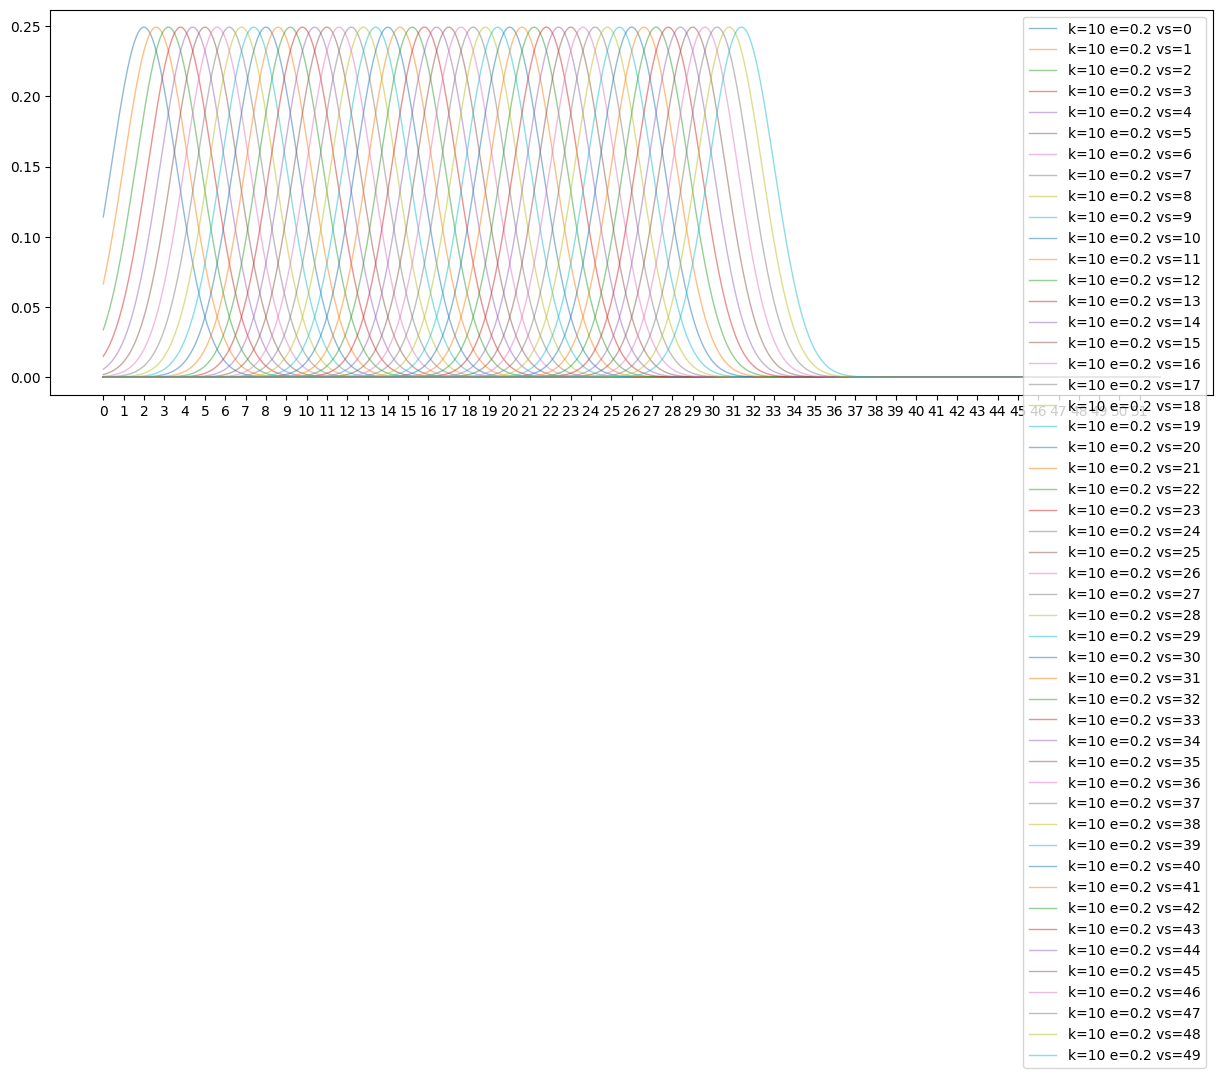

In [11]:
k = 10
e = 0.2

plt.figure(figsize=(15, 5))
x_max = 52
X = np.linspace(0, x_max, 1000)

for vs in range(50):
    mu = (k-vs)*e + vs*(1-e)
    sigma = k*e*(1-e)

    norm_pdf = stats.norm.pdf(x=X, loc=mu, scale=sigma)
    norm_pdf = norm_pdf
    norm_pdf_max = np.max(norm_pdf)
    print(mu)

    plt.plot(X, norm_pdf, lw=1, alpha=0.5, label=f"k={k} e={e} vs={vs}")
    plt.legend()
    plt.xticks(np.arange(0, x_max, 1))


plt.show()